In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [110]:
df=pd.read_csv(r"D:\Arnita\Iris.csv")

In [111]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [113]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [114]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [115]:
x=df.drop(columns=["Species"])
y=df["Species"]

In [124]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=0)

In [125]:
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.fit_transform(x_test)

In [126]:
model=LogisticRegression()
model.fit(x_train_scaled, y_train)
lr_pred=model.predict(x_test_scaled)
lr_accuracy=accuracy_score(y_test, lr_pred)

In [127]:
model=RandomForestClassifier()
model.fit(x_train, y_train)
rf_pred=model.predict(x_test)
rf_accuracy=accuracy_score(y_test, rf_pred)

In [128]:
model=SVC()
model.fit(x_train_scaled, y_train)
svm_pred=model.predict(x_test_scaled)
svm_accuracy=accuracy_score(y_test, svm_pred)

In [129]:
print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("SVM Accuracy:", svm_accuracy)

Logistic Regression Accuracy: 0.9333333333333333
Random Forest Accuracy: 1.0
SVM Accuracy: 0.9


In [130]:
print("Logistic Regression Report:\n", classification_report(y_test, lr_pred))
print("Random Forest Report:\n", classification_report(y_test, rf_pred))
print("SVM Report:\n", classification_report(y_test, svm_pred))

Logistic Regression Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.85      0.92        13
 Iris-virginica       0.75      1.00      0.86         6

       accuracy                           0.93        30
      macro avg       0.92      0.95      0.92        30
   weighted avg       0.95      0.93      0.94        30

Random Forest Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

SVM Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor 

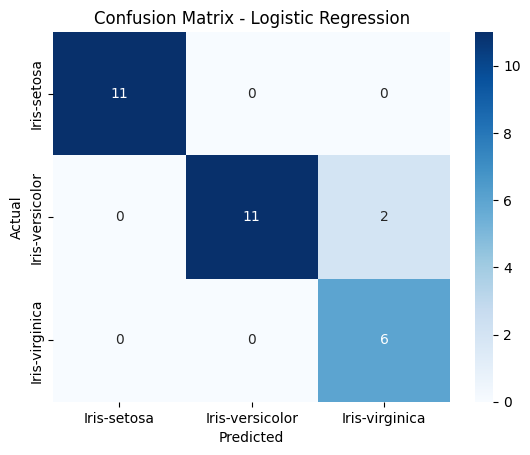

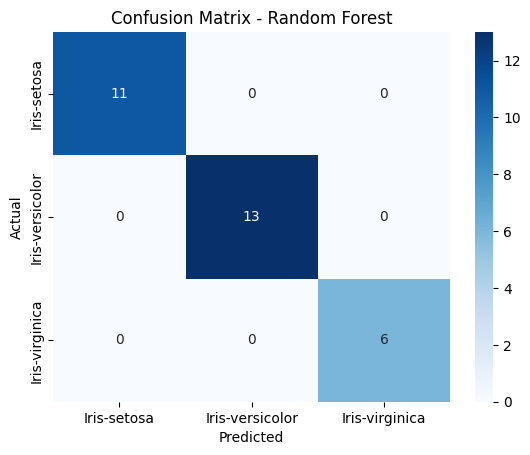

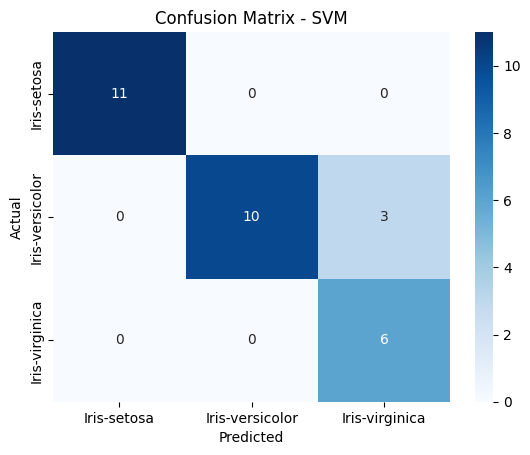

In [131]:
# Logistic Regression 
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# Random Forest 
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


# SVM 
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()